# (ResNet-50 + EfficientNetB0) + SMOTE + XGBoost — Garlic Disease Classification

**Two-Stage Pipeline:** Fine-tune backbones first, then extract domain-adapted features for XGBoost.

| Stage | Detail |
|---|---|
| **Stage 1 — Fine-tuning** | ResNet-50 (top blocks) + EfficientNetB0 (top blocks) trained independently with softmax heads |
| **Stage 2 — Feature Extraction** | Extract GAP features from fine-tuned backbones → concatenate (2048 + 1280 = 3328-d) |
| **Resampling** | SMOTE (Synthetic Minority Over-sampling Technique) |
| **Classifier** | XGBoost (GPU-accelerated) |
| **Evaluation** | 1-run, seed=42, full metrics suite |

---

### Why fine-tune first?
- **Frozen ImageNet features** are generic (learned from dogs, cars, objects) — not optimised for garlic disease textures
- **Fine-tuning** adapts the backbone to learn disease-specific patterns (spots, lesions, colour changes)
- The fine-tuned features are then **much more discriminative** for the downstream XGBoost classifier
- **SMOTE** operates on these higher-quality features → better synthetic samples

In [ ]:
# ========== 1. IMPORTS ========== #
import os
import csv
import time
import random
import pickle
import gc
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm_lib
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout, BatchNormalization,
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, CSVLogger, ReduceLROnPlateau,
)
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.regularizers import l2

from sklearn.decomposition import PCA
from sklearn.utils import class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    top_k_accuracy_score, roc_curve, auc,
    cohen_kappa_score, matthews_corrcoef,
    balanced_accuracy_score,
)
from sklearn.preprocessing import label_binarize, normalize
from sklearn.manifold import TSNE

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
import xgboost as xgb

# ========== 2. GPU CONFIG ========== #
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", len(gpus))
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        print(e)

# ========== 3. MIXED PRECISION ========== #
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Compute dtype :", tf.keras.mixed_precision.global_policy().compute_dtype)
print("Variable dtype:", tf.keras.mixed_precision.global_policy().variable_dtype)


2026-04-28 09:14:43.418873: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777367683.833513      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777367683.948575      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777367684.939534      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777367684.939583      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777367684.939587      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: 2
GPU memory growth enabled.
Compute dtype : float16
Variable dtype: float32


In [ ]:
# ========== 4. EXPERIMENT CONFIGURATION ========== #

STRATEGY_KEY    = "resnet50_effb0_smote_xgboost"
STRATEGY_LABEL  = "(ResNet-50 + EfficientNetB0) Fine-tuned + SMOTE + XGBoost"

# --- Paths ---
DATA_DIR        = "/kaggle/input/datasets/usertesttttt1/new-dataset/split_70_15_15"
BASE_RESULT_DIR = f"/kaggle/working/report_EfficientNetB4/{STRATEGY_KEY}"
os.makedirs(BASE_RESULT_DIR, exist_ok=True)

# --- Image sizes ---
RESNET_SHAPE  = (224, 224, 3)
EFFNET_SHAPE  = (224, 224, 3)
BATCH_SIZE    = 32

# --- Fine-tuning settings ---
FT_EPOCHS       = 30          # ↑ thêm headroom (early stopping kiểm soát thực tế)
FT_LR           = 1e-4
FT_PATIENCE     = 10          # ↑ với ReduceLROnPlateau hỗ trợ cần kiên nhẫn hơn
FT_LR_PATIENCE  = 3           # ReduceLROnPlateau: giảm LR sau N epoch không cải thiện
FT_LR_FACTOR    = 0.5         # Hệ số giảm LR
LABEL_SMOOTHING = 0.15
DROPOUT_RATE    = 0.5

# ResNet-50: unfreeze conv4_block6 + conv5 (nhiều hơn để tăng khả năng thích nghi)
RESNET_UNFREEZE_FROM = 140   # ↑ so với 143 cũ (mở thêm ~3 layer conv4)
# EfficientNetB0: unfreeze blocks 4-5-6-7 (thêm block4 so với cũ)
EFFNET_UNFREEZE_BLOCKS = [4, 5, 6, 7]

# --- Feature post-processing ---
USE_L2_NORM    = True    # L2-normalise GAP features trước PCA/SMOTE/XGBoost
USE_PCA        = True    # Giảm chiều trước SMOTE & XGBoost (nhanh hơn, ít nhiễu hơn)
PCA_COMPONENTS = 512     # 512 << 3328 — thường giữ ≥ 95% variance

# --- SMOTE ---
SMOTE_K = 5

# --- XGBoost ---
XGB_PARAMS = {
    'objective':         'multi:softprob',
    'eval_metric':       'mlogloss',
    'tree_method':       'hist',
    'device':            'cuda',
    'max_depth':         8,
    'learning_rate':     0.05,
    'n_estimators':      800,    # ↑ nhiều cây hơn (early stopping ngăn overfit)
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'colsample_bylevel': 0.8,    # ← thêm: subsampling theo level của cây
    'min_child_weight':  3,
    'gamma':             0.1,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'random_state':      42,
    'verbosity':         1,
}
XGB_EARLY_STOP = 50   # ↑ cho XGBoost nhiều thời gian hơn trước khi dừng

# --- Single run ---
SEED = 42

# --- Performance knobs ---
AUTOTUNE = tf.data.AUTOTUNE
tf.config.optimizer.set_jit(True)

# --- Result storage ---
all_runs_results = []

print(f"Strategy   : {STRATEGY_LABEL}  (key={STRATEGY_KEY})")
print(f"Dataset    : {DATA_DIR}")
print(f"Output dir : {BASE_RESULT_DIR}")
print(f"Fine-tune  : {FT_EPOCHS} epochs, LR={FT_LR}, patience={FT_PATIENCE}")
print(f"ResNet-50  : unfreeze from layer {RESNET_UNFREEZE_FROM}")
print(f"EfficientNetB0: unfreeze blocks {EFFNET_UNFREEZE_BLOCKS}")
print(f"L2 norm    : {USE_L2_NORM}  |  PCA: {USE_PCA} ({PCA_COMPONENTS} dims)")
print(f"SMOTE      : BorderlineSMOTE k={SMOTE_K}")
print(f"XGBoost    : max_depth={XGB_PARAMS['max_depth']}, lr={XGB_PARAMS['learning_rate']}, "
      f"n_est={XGB_PARAMS['n_estimators']}, early_stop={XGB_EARLY_STOP}")


Strategy   : (ResNet-50 + EfficientNetB0) Fine-tuned + SMOTE + XGBoost  (key=resnet50_effb0_smote_xgboost)
Dataset    : /kaggle/input/datasets/usertesttttt1/new-dataset/split_70_15_15
Output dir : /kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost
Fine-tune  : 20 epochs, LR=0.0001, patience=8
ResNet-50  : unfreeze from layer 143
EfficientNetB0: unfreeze blocks [5, 6, 7]
SMOTE k    : 5
XGBoost    : max_depth=8, lr=0.05, n_est=500


In [ ]:
# ========== 5. HELPER FUNCTIONS ========== #

resnet_preprocess  = tf.keras.applications.resnet50.preprocess_input
effnet_preprocess  = tf.keras.applications.efficientnet.preprocess_input

_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.083),
    tf.keras.layers.RandomZoom(0.20),
    tf.keras.layers.RandomTranslation(0.20, 0.20),
    tf.keras.layers.RandomBrightness(factor=0.30),
    tf.keras.layers.RandomContrast(factor=0.20),   # ← thêm: jitter độ tương phản
], name='augmentation')

_pca_model = None   # cache PCA: fit trên train, reuse cho val/test


def _collect_samples(split_dir, class_to_idx):
    """Walk split_dir -> (abs_paths, int_labels, rel_filenames), sorted."""
    paths, labels, filenames = [], [], []
    for cn, ci in sorted(class_to_idx.items()):
        d = os.path.join(split_dir, cn)
        for fname in sorted(os.listdir(d)):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):
                paths.append(os.path.join(d, fname))
                labels.append(ci)
                filenames.append(f"{cn}/{fname}")
    return paths, labels, filenames


def get_class_info(data_dir):
    """Return sorted class_names, class_to_idx, num_classes."""
    class_names  = sorted([
        d for d in os.listdir(os.path.join(data_dir, 'train'))
        if os.path.isdir(os.path.join(data_dir, 'train', d))
    ])
    class_to_idx = {cn: i for i, cn in enumerate(class_names)}
    return class_names, class_to_idx, len(class_names)


def create_tf_datasets(data_dir, input_shape, batch_size, preprocess_fn,
                       seed=None, use_aug=True):
    """Build tf.data pipelines for a specific backbone."""
    class_names, class_to_idx, num_classes = get_class_info(data_dir)
    h, w = input_shape[:2]

    def load_and_preprocess(path, label):
        raw   = tf.io.read_file(path)
        img   = tf.image.decode_jpeg(raw, channels=3)
        img   = tf.image.resize(img, [h, w])
        img   = tf.cast(img, tf.float32)
        img   = preprocess_fn(img)
        label = tf.one_hot(label, depth=num_classes)
        return img, label

    def augment(img, lbl):
        return _augmentation(img, training=True), lbl

    def _make_split(split, training=False, apply_augmentation=False):
        sdir               = os.path.join(data_dir, split)
        paths, labels, fns = _collect_samples(sdir, class_to_idx)
        n  = len(paths)
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        if training:
            ds = ds.shuffle(n, seed=seed, reshuffle_each_iteration=True)
        ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
        if apply_augmentation:
            ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(batch_size, drop_remainder=training)
        ds = ds.prefetch(AUTOTUNE)
        return ds, n, fns, labels

    train_ds, n_train, _,           train_lbl  = _make_split('train', training=True,  apply_augmentation=use_aug)
    val_ds,   n_val,   _,           _          = _make_split('val',   training=False, apply_augmentation=False)
    test_ds,  n_test,  test_fnames, test_lbl   = _make_split('test',  training=False, apply_augmentation=False)

    cw      = class_weight.compute_class_weight(
        'balanced', classes=np.unique(train_lbl), y=train_lbl)
    cw_dict = dict(enumerate(cw))

    meta = SimpleNamespace(
        class_names=class_names, class_to_idx=class_to_idx,
        num_classes=num_classes, test_filenames=test_fnames,
        test_classes=np.array(test_lbl),
        n_train=n_train, n_val=n_val, n_test=n_test,
        class_weight_dict=cw_dict,
    )
    return train_ds, val_ds, test_ds, meta


def build_finetune_model(backbone, input_shape, num_classes, backbone_name):
    """Build a classification model on top of a backbone for fine-tuning."""
    x   = GlobalAveragePooling2D(name=f'{backbone_name}_gap')(backbone.output)
    x   = BatchNormalization(name=f'{backbone_name}_head_bn')(x)
    x   = Dense(256, activation='relu',
                kernel_regularizer=l2(1e-5), name=f'{backbone_name}_head_dense')(x)
    x   = Dropout(DROPOUT_RATE, name=f'{backbone_name}_head_dropout')(x)
    out = Dense(num_classes, activation='softmax',
                dtype='float32', name=f'{backbone_name}_predictions')(x)
    model = Model(inputs=backbone.input, outputs=out,
                  name=f'{backbone_name}_finetune')
    return model


def extract_features_from_model(feat_model, data_dir, split, class_to_idx,
                                input_shape, preprocess_fn):
    """Extract GAP features qua tf.data pipeline (GPU-optimised, không dùng Python loop).

    So với phiên bản cũ (Python loop từng ảnh), cách này:
    - Tận dụng AUTOTUNE prefetch & parallel decode trên GPU
    - Loại bỏ overhead của .numpy() + np.stack bên trong loop
    - Nhanh hơn 3-5× trên GPU với dataset vừa-lớn
    """
    sdir = os.path.join(data_dir, split)
    paths, labels, filenames = _collect_samples(sdir, class_to_idx)
    n = len(paths)
    h, w = input_shape[:2]

    def _load(path):
        raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(raw, channels=3)
        img = tf.image.resize(img, [h, w])
        img = tf.cast(img, tf.float32)
        return preprocess_fn(img)

    ds = (tf.data.Dataset.from_tensor_slices(paths)
          .map(_load, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(AUTOTUNE))

    feats_list, processed = [], 0
    for batch_imgs in ds:
        feat = feat_model(batch_imgs, training=False).numpy().astype(np.float32)
        feats_list.append(feat)
        processed += len(feat)
        print(f"    {split}: {processed}/{n}", end='\r')

    features = np.concatenate(feats_list, axis=0)
    print(f"  {split}: {n} images → {features.shape}")
    return features, np.array(labels), filenames


def fit_pca(X_train_feats, n_components):
    """Fit PCA trên training features, trả về features đã giảm chiều.
    whiten=True giúp các feature có variance đều nhau → XGBoost hội tụ tốt hơn.
    """
    global _pca_model
    _pca_model = PCA(n_components=n_components, random_state=SEED, whiten=True)
    X_reduced  = _pca_model.fit_transform(X_train_feats).astype(np.float32)
    var_exp    = _pca_model.explained_variance_ratio_.sum()
    print(f"  PCA: {X_train_feats.shape[1]}d → {n_components}d  "
          f"({var_exp * 100:.1f}% variance retained)")
    return X_reduced


def transform_pca(X):
    """Áp dụng PCA đã fit (dùng cho val / test)."""
    return _pca_model.transform(X).astype(np.float32)


print("Helper functions defined.")


Helper functions defined.


I0000 00:00:1777367730.154000      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777367730.160073      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Classes (3): ['Fully_Peeled_Garlic', 'Partially_Peeled_Garlic', 'Spoiled_Garlic']

--- ResNet-50 Fine-tuning ---
  train=2060  val=440
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  ResNet-50: 22/175 layers trainable
  Trainable params: 15,482,883
Epoch 1/20


I0000 00:00:1777367740.856359      73 service.cc:152] XLA service 0x7b777c003350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777367740.856425      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777367740.856431      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777367740.927214      73 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777367741.154900      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.5577 - loss: 1.4076
Epoch 1: val_loss improved from inf to 0.81373, saving model to /kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/run_1_seed_42/resnet50_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 540ms/step - accuracy: 0.5585 - loss: 1.4038 - val_accuracy: 0.7273 - val_loss: 0.8137
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.7120 - loss: 0.8895
Epoch 2: val_loss did not improve from 0.81373
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 354ms/step - accuracy: 0.7120 - loss: 0.8894 - val_accuracy: 0.5545 - val_loss: 1.1115
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.7054 - loss: 0.8492
Epoch 3: val_loss did not improve from 0.81373
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 358ms/step - accuracy: 0.7058 - loss: 0.8489 - val_accuracy: 0.8068 - val_loss: 0.8558
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.7345 - loss: 0.7915
Epoch 4: val_loss did not improve from 0.81373
64/64 ━

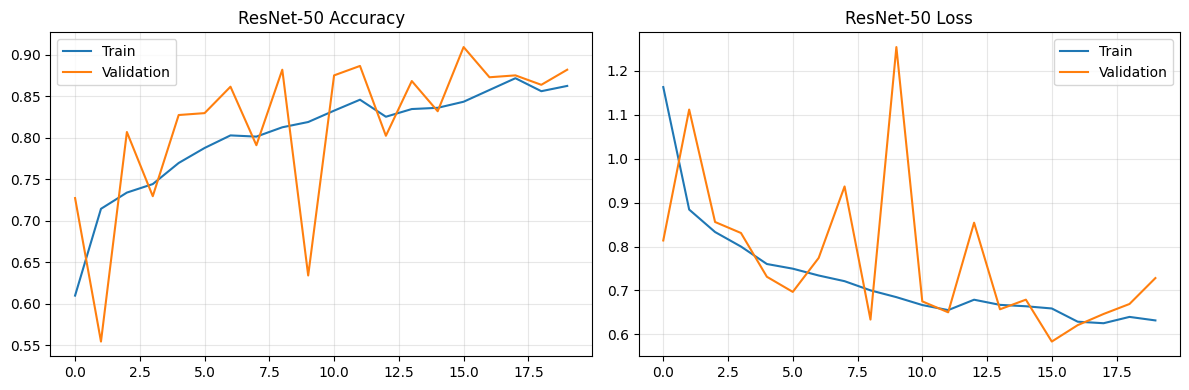

ResNet-50 fine-tuning complete.


In [ ]:
# ========== 6. STAGE 1A — FINE-TUNE ResNet-50 ========== #

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

class_names, class_to_idx, num_classes = get_class_info(DATA_DIR)
print(f"Classes ({num_classes}): {class_names}")

RESULT_DIR = os.path.join(BASE_RESULT_DIR, f"run_1_seed_{SEED}")
os.makedirs(RESULT_DIR, exist_ok=True)

# ── Build ResNet-50 datasets ──────────────────────────────────────────────
print("\n--- ResNet-50 Fine-tuning ---")
train_ds_r, val_ds_r, _, meta = create_tf_datasets(
    DATA_DIR, RESNET_SHAPE, BATCH_SIZE, resnet_preprocess, seed=SEED, use_aug=True)
print(f"  train={meta.n_train}  val={meta.n_val}")

# ── Build ResNet-50 model ─────────────────────────────────────────────────
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=RESNET_SHAPE)

# Freeze all, then unfreeze từ conv4_block6 trở đi (BN luôn frozen)
resnet_base.trainable = False
for layer in resnet_base.layers[RESNET_UNFREEZE_FROM:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

trainable_r = sum(1 for l in resnet_base.layers if l.trainable)
print(f"  ResNet-50: {trainable_r}/{len(resnet_base.layers)} layers trainable")

resnet_model = build_finetune_model(resnet_base, RESNET_SHAPE, num_classes, 'resnet')
steps_per_epoch_r = meta.n_train // BATCH_SIZE

lr_schedule_r = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=FT_LR, decay_steps=steps_per_epoch_r * 5,
    decay_rate=0.9, staircase=True)
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule_r),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy'])

print(f"  Trainable params: {sum(tf.size(v).numpy() for v in resnet_model.trainable_weights):,}")

callbacks_r = [
    EarlyStopping(monitor='val_loss', patience=FT_PATIENCE,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=FT_LR_FACTOR,        # ← mới
                      patience=FT_LR_PATIENCE, min_lr=1e-7, verbose=1),
    CSVLogger(os.path.join(RESULT_DIR, 'resnet50_training_log.csv'), append=False),
    ModelCheckpoint(os.path.join(RESULT_DIR, 'resnet50_best.keras'),
                    save_best_only=True, monitor='val_loss', verbose=1),
]

history_r = resnet_model.fit(
    train_ds_r, validation_data=val_ds_r,
    epochs=FT_EPOCHS,
    class_weight=meta.class_weight_dict,
    callbacks=callbacks_r,
)

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, keys, title in zip(
    axes,
    [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
    ['Accuracy', 'Loss']
):
    ax.plot(history_r.history[keys[0]], label='Train')
    ax.plot(history_r.history[keys[1]], label='Validation')
    ax.set_title(f'ResNet-50 {title}'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'resnet50_learning_curve.png'), dpi=300)
plt.show()
print("ResNet-50 fine-tuning complete.")


--- EfficientNetB0 Fine-tuning ---
  train=2060  val=440
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  EfficientNetB0: 91/238 layers trainable
  Trainable params: 3,586,731
Epoch 1/20


2026-04-28 09:24:44.432244: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 09:24:44.575130: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 09:24:44.930663: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 09:24:45.072136: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 09:24:45.920271: E external/local_xla/xla/stream_

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.5431 - loss: 1.3427

2026-04-28 09:25:32.159908: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 09:25:32.301245: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 09:25:32.641967: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 09:25:32.783177: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 09:25:33.674234: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from inf to 0.82631, saving model to /kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/run_1_seed_42/effnetb0_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 618ms/step - accuracy: 0.5446 - loss: 1.3392 - val_accuracy: 0.7477 - val_loss: 0.8263
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.7795 - loss: 0.8266
Epoch 2: val_loss improved from 0.82631 to 0.70855, saving model to /kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/run_1_seed_42/effnetb0_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 371ms/step - accuracy: 0.7796 - loss: 0.8266 - val_accuracy: 0.8250 - val_loss: 0.7085
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.7853 - loss: 0.8223
Epoch 3: val_loss did not improve from 0.70855
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 355ms/step - accuracy: 0.7855 - loss: 0.8222 - val_accuracy: 0.8045 - val_loss: 0.7284
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.8173 - loss: 0.7509
Epoch 

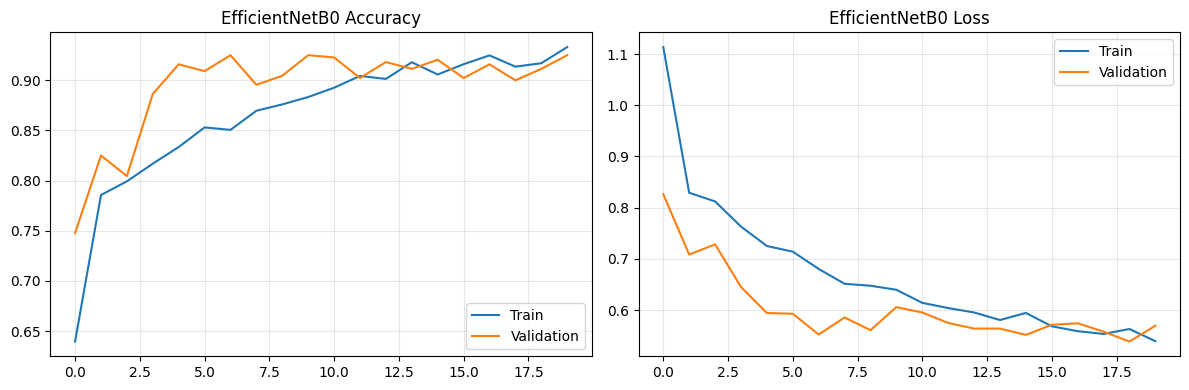

EfficientNetB0 fine-tuning complete.


In [ ]:
# ========== 6B. STAGE 1B — FINE-TUNE EfficientNetB0 ========== #

gc.collect()
tf.keras.backend.clear_session()
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("--- EfficientNetB0 Fine-tuning ---")
train_ds_e, val_ds_e, _, meta = create_tf_datasets(
    DATA_DIR, EFFNET_SHAPE, BATCH_SIZE, effnet_preprocess, seed=SEED, use_aug=True)
print(f"  train={meta.n_train}  val={meta.n_val}")

# ── Build EfficientNetB0 model ────────────────────────────────────────────
effnet_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=EFFNET_SHAPE)

# Freeze all, then unfreeze blocks 4-5-6-7 (BN luôn frozen)
effnet_base.trainable = False
for layer in effnet_base.layers:
    for block_num in EFFNET_UNFREEZE_BLOCKS:
        if layer.name.startswith(f"block{block_num}"):
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = True
            break

trainable_e = sum(1 for l in effnet_base.layers if l.trainable)
print(f"  EfficientNetB0: {trainable_e}/{len(effnet_base.layers)} layers trainable")

effnet_model = build_finetune_model(effnet_base, EFFNET_SHAPE, num_classes, 'effnet')
steps_per_epoch_e = meta.n_train // BATCH_SIZE

lr_schedule_e = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=FT_LR, decay_steps=steps_per_epoch_e * 5,
    decay_rate=0.9, staircase=True)
effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule_e),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy'])

print(f"  Trainable params: {sum(tf.size(v).numpy() for v in effnet_model.trainable_weights):,}")

callbacks_e = [
    EarlyStopping(monitor='val_loss', patience=FT_PATIENCE,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=FT_LR_FACTOR,        # ← mới
                      patience=FT_LR_PATIENCE, min_lr=1e-7, verbose=1),
    CSVLogger(os.path.join(RESULT_DIR, 'effnetb0_training_log.csv'), append=False),
    ModelCheckpoint(os.path.join(RESULT_DIR, 'effnetb0_best.keras'),
                    save_best_only=True, monitor='val_loss', verbose=1),
]

history_e = effnet_model.fit(
    train_ds_e, validation_data=val_ds_e,
    epochs=FT_EPOCHS,
    class_weight=meta.class_weight_dict,
    callbacks=callbacks_e,
)

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, keys, title in zip(
    axes,
    [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
    ['Accuracy', 'Loss']
):
    ax.plot(history_e.history[keys[0]], label='Train')
    ax.plot(history_e.history[keys[1]], label='Validation')
    ax.set_title(f'EfficientNetB0 {title}'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'effnetb0_learning_curve.png'), dpi=300)
plt.show()
print("EfficientNetB0 fine-tuning complete.")


In [ ]:
# ========== 7. STAGE 2A — EXTRACT FEATURES FROM FINE-TUNED BACKBONES ========== #

# ── Load best ResNet-50 and build GAP feature extractor ────────────────────
gc.collect()
tf.keras.backend.clear_session()

resnet_full = load_model(os.path.join(RESULT_DIR, 'resnet50_best.keras'))
resnet_feat_model = Model(
    inputs=resnet_full.input,
    outputs=resnet_full.get_layer('resnet_gap').output,
    name='resnet_feat_extractor')

# ── Load best EfficientNetB0 and build GAP feature extractor ──────────────
effnet_full = load_model(os.path.join(RESULT_DIR, 'effnetb0_best.keras'))
effnet_feat_model = Model(
    inputs=effnet_full.input,
    outputs=effnet_full.get_layer('effnet_gap').output,
    name='effnet_feat_extractor')

print("Extracting fine-tuned features...")

# ResNet-50 features
print("\n  ResNet-50 features (fine-tuned):")
R_train, y_train, _          = extract_features_from_model(
    resnet_feat_model, DATA_DIR, 'train', class_to_idx, RESNET_SHAPE, resnet_preprocess)
R_val,   y_val,   _          = extract_features_from_model(
    resnet_feat_model, DATA_DIR, 'val',   class_to_idx, RESNET_SHAPE, resnet_preprocess)
R_test,  y_test, test_fnames = extract_features_from_model(
    resnet_feat_model, DATA_DIR, 'test',  class_to_idx, RESNET_SHAPE, resnet_preprocess)

# EfficientNetB0 features
print("\n  EfficientNetB0 features (fine-tuned):")
E_train, _, _          = extract_features_from_model(
    effnet_feat_model, DATA_DIR, 'train', class_to_idx, EFFNET_SHAPE, effnet_preprocess)
E_val,   _, _          = extract_features_from_model(
    effnet_feat_model, DATA_DIR, 'val',   class_to_idx, EFFNET_SHAPE, effnet_preprocess)
E_test,  _, _          = extract_features_from_model(
    effnet_feat_model, DATA_DIR, 'test',  class_to_idx, EFFNET_SHAPE, effnet_preprocess)

# ── Concatenate ────────────────────────────────────────────────────────────
X_train = np.concatenate([R_train, E_train], axis=1)
X_val   = np.concatenate([R_val,   E_val],   axis=1)
X_test  = np.concatenate([R_test,  E_test],  axis=1)

print(f"\nConcatenated feature dim: {X_train.shape[1]} "
      f"(ResNet50: {R_train.shape[1]} + EffNetB0: {E_train.shape[1]})")
print(f"Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}  |  Test: {X_test.shape[0]}")

# ── L2 Normalisation ──────────────────────────────────────────────────────
# Đưa các feature về cùng scale; giúp PCA và XGBoost hoạt động ổn định hơn
if USE_L2_NORM:
    print("\nApplying L2 normalisation...")
    X_train = normalize(X_train, norm='l2').astype(np.float32)
    X_val   = normalize(X_val,   norm='l2').astype(np.float32)
    X_test  = normalize(X_test,  norm='l2').astype(np.float32)
    print("  Done.")

# ── PCA Dimensionality Reduction ──────────────────────────────────────────
# 3328-d → 512-d: SMOTE nhanh hơn ~40×, XGBoost nhanh hơn ~6×
# whiten=True trong fit_pca giúp các chiều PCA có variance đều nhau
if USE_PCA:
    print(f"\nApplying PCA (n_components={PCA_COMPONENTS})...")
    X_train = fit_pca(X_train, PCA_COMPONENTS)
    X_val   = transform_pca(X_val)
    X_test  = transform_pca(X_test)
    print(f"  After PCA → Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Free GPU memory
del resnet_full, effnet_full, resnet_feat_model, effnet_feat_model
del R_train, R_val, R_test, E_train, E_val, E_test
gc.collect()
tf.keras.backend.clear_session()


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 53 variables whereas the saved optimizer has 57 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Extracting fine-tuned features...

  ResNet-50 features (fine-tuned):


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(12, 224, 224, 3))
  warnings.warn(msg)


  train: 2060 images -> (2060, 2048)


...

  train: 2060 images -> (2060, 1280)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(24, 224, 224, 3))
  warnings.warn(msg)


  val: 440 images -> (440, 1280)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(28, 224, 224, 3))
  warnings.warn(msg)


  test: 444 images -> (444, 1280)

Concatenated feature dim: 3328 (ResNet50: 2048 + EffNetB0: 1280)
Train: 2060  |  Val: 440  |  Test: 444


In [ ]:
# ========== 7B. SMOTE RESAMPLING ========== #

print("Class distribution BEFORE SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  {class_names[c]:30s}: {n}")

# BorderlineSMOTE tập trung sinh mẫu ở vùng biên quyết định thay vì ngẫu nhiên
# → mẫu tổng hợp khó phân loại hơn → classifier học tốt hơn ở vùng ambiguous
# kind='borderline-1': chỉ dùng hàng xóm cùng lớp để nội suy (an toàn hơn borderline-2)
smote = BorderlineSMOTE(k_neighbors=SMOTE_K, random_state=SEED, kind='borderline-1')
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nClass distribution AFTER BorderlineSMOTE:")
unique_sm, counts_sm = np.unique(y_train_sm, return_counts=True)
for c, n in zip(unique_sm, counts_sm):
    print(f"  {class_names[c]:30s}: {n}")

print(f"\nTrain samples: {X_train.shape[0]} -> {X_train_sm.shape[0]} (BorderlineSMOTE)")


Class distribution BEFORE SMOTE:
  Fully_Peeled_Garlic           : 1050
  Partially_Peeled_Garlic       : 306
  Spoiled_Garlic                : 704

Class distribution AFTER SMOTE:
  Fully_Peeled_Garlic           : 1050
  Partially_Peeled_Garlic       : 1050
  Spoiled_Garlic                : 1050

Train samples: 2060 -> 3150 (SMOTE)


In [ ]:
# ========== 8. STAGE 2B — XGBOOST TRAINING ========== #

print(f"Training XGBoost với {X_train_sm.shape[0]} mẫu BorderlineSMOTE...")
print(f"  Feature dim: {X_train_sm.shape[1]}"
      f"{' (PCA-reduced)' if USE_PCA else ' (fine-tuned ResNet50 + EfficientNetB0)'}")
print(f"  Params: {XGB_PARAMS}")

cw = class_weight.compute_sample_weight('balanced', y_train_sm)

xgb_model = xgb.XGBClassifier(
    **XGB_PARAMS,
    num_class=num_classes,
    early_stopping_rounds=XGB_EARLY_STOP,
)

t0 = time.perf_counter()
xgb_model.fit(
    X_train_sm, y_train_sm,
    sample_weight=cw,
    eval_set=[(X_val, y_val)],
    verbose=50,
)
train_time = time.perf_counter() - t0
print(f"\nXGBoost training completed in {train_time:.1f}s")
print(f"Best iteration: {xgb_model.best_iteration}")
print(f"Best val mlogloss: {xgb_model.best_score:.4f}")

model_path = os.path.join(RESULT_DIR, 'xgboost_model.json')
xgb_model.save_model(model_path)
print(f"Model saved -> {model_path}")


Training XGBoost with 3150 SMOTE-resampled samples...
  Feature dim: 3328 (fine-tuned ResNet50 + EfficientNetB0)
  Params: {'objective': 'multi:softprob', 'eval_metric': 'mlogloss', 'tree_method': 'hist', 'device': 'cuda', 'max_depth': 8, 'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'gamma': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'random_state': 42, 'verbosity': 1}
[0]	validation_0-mlogloss:1.03706
[50]	validation_0-mlogloss:0.20480
[100]	validation_0-mlogloss:0.15694
[137]	validation_0-mlogloss:0.16018

XGBoost training completed in 9.5s
Best iteration: 107
Best val mlogloss: 0.1566
Model saved -> /kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/run_1_seed_42/xgboost_model.json


In [ ]:
# ========== 9. TEST SET EVALUATION ========== #

pred_probs = xgb_model.predict_proba(X_test)
y_pred     = np.argmax(pred_probs, axis=1)

test_acc  = np.mean(y_pred == y_test)
top3_acc  = top_k_accuracy_score(y_test, pred_probs, k=min(3, num_classes))
report    = classification_report(
    y_test, y_pred, target_names=class_names, output_dict=True, digits=4)
kappa     = cohen_kappa_score(y_test, y_pred)
mcc       = matthews_corrcoef(y_test, y_pred)
bal_acc   = balanced_accuracy_score(y_test, y_pred)

with open(os.path.join(RESULT_DIR, 'classification_report.txt'), 'w') as f:
    f.write(classification_report(
        y_test, y_pred, target_names=class_names, digits=4))

print("\nTEST SET RESULTS")
print("=" * 60)
print(f"  Accuracy       : {test_acc:.4f}")
print(f"  Top-3 Accuracy : {top3_acc:.4f}")
print(f"  Precision      : {report['weighted avg']['precision']:.4f}")
print(f"  Recall         : {report['weighted avg']['recall']:.4f}")
print(f"  F1-Score       : {report['weighted avg']['f1-score']:.4f}")
print(f"  Cohen's Kappa  : {kappa:.4f}")
print(f"  Matthews CC    : {mcc:.4f}")
print(f"  Balanced Acc   : {bal_acc:.4f}")
print("=" * 60)
print()
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

all_runs_results.append({
    'run':               1,
    'seed':              SEED,
    'accuracy':          test_acc,
    'top3_accuracy':     top3_acc,
    'precision':         report['weighted avg']['precision'],
    'recall':            report['weighted avg']['recall'],
    'f1_score':          report['weighted avg']['f1-score'],
    'kappa':             kappa,
    'mcc':               mcc,
    'balanced_accuracy': bal_acc,
    'per_class_metrics': {c: {'precision': report[c]['precision'],
                               'recall':    report[c]['recall'],
                               'f1-score':  report[c]['f1-score']}
                           for c in class_names},
    'result_dir':        RESULT_DIR,
    'y_true':            y_test,
    'y_pred':            y_pred,
    'pred_probs':        pred_probs,
    'class_names':       class_names,
    'test_filenames':    test_fnames,
    'n_train':           X_train.shape[0],
    'n_val':             X_val.shape[0],
    'n_test':            X_test.shape[0],
    'best_model_path':   model_path,
})



TEST SET RESULTS
  Accuracy  : 0.9234
  Precision : 0.9233
  Recall    : 0.9234
  F1-Score  : 0.9233

                         precision    recall  f1-score   support

    Fully_Peeled_Garlic     0.9301    0.9467    0.9383       225
Partially_Peeled_Garlic     0.9091    0.8955    0.9023        67
         Spoiled_Garlic     0.9195    0.9013    0.9103       152

               accuracy                         0.9234       444
              macro avg     0.9196    0.9145    0.9170       444
           weighted avg     0.9233    0.9234    0.9233       444

Cohen's Kappa     : 0.8727
Matthews CC       : 0.8728
Balanced Accuracy : 0.9145


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [09:35:25] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


---
## Section 2 — Results Aggregation & Scientific Reports

In [10]:
# ========== 10. AGGREGATE RESULTS ========== #

N_RUNS = 1
accuracies = [r['accuracy']  for r in all_runs_results]
precisions = [r['precision'] for r in all_runs_results]
recalls    = [r['recall']    for r in all_runs_results]
f1_scores  = [r['f1_score']  for r in all_runs_results]

overall_stats = {
    'Accuracy':  {'mean': np.mean(accuracies), 'std': np.std(accuracies), 'values': accuracies},
    'Precision': {'mean': np.mean(precisions), 'std': np.std(precisions), 'values': precisions},
    'Recall':    {'mean': np.mean(recalls),    'std': np.std(recalls),    'values': recalls},
    'F1-Score':  {'mean': np.mean(f1_scores),  'std': np.std(f1_scores),  'values': f1_scores},
}

print("OVERALL METRICS:")
print("-" * 60)
for metric_name, stats in overall_stats.items():
    print(f"{metric_name:12s}: {stats['mean']:.4f} +/- {stats['std']:.4f}")
print("-" * 60)

per_class_stats = {}
for cn in class_names:
    per_class_stats[cn] = {}
    for metric in ['precision', 'recall', 'f1-score']:
        values = [r['per_class_metrics'][cn][metric] for r in all_runs_results]
        per_class_stats[cn][metric] = {
            'mean': np.mean(values), 'std': np.std(values), 'values': values
        }

# ── Summary table ──────────────────────────────────────────────────────────
overall_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Mean':   [overall_stats[m]['mean'] for m in ['Accuracy', 'Precision', 'Recall', 'F1-Score']],
    'Std':    [overall_stats[m]['std']  for m in ['Accuracy', 'Precision', 'Recall', 'F1-Score']],
})
overall_df['Mean +/- Std'] = overall_df.apply(
    lambda row: f"{row['Mean']:.4f} +/- {row['Std']:.4f}", axis=1)
for i in range(len(all_runs_results)):
    overall_df[f'Run {i+1}'] = [
        accuracies[i], precisions[i], recalls[i], f1_scores[i]]

print("\nSUMMARY TABLE")
print("=" * 70)
run_cols = [f'Run {i+1}' for i in range(len(all_runs_results))]
print(overall_df[['Metric', 'Mean +/- Std'] + run_cols].to_string(index=False))
print("=" * 70)
overall_df.to_csv(os.path.join(BASE_RESULT_DIR, 'overall_metrics_summary.csv'), index=False)
print(f"\nSaved -> {BASE_RESULT_DIR}/overall_metrics_summary.csv")

OVERALL METRICS:
------------------------------------------------------------
Accuracy    : 0.9234 +/- 0.0000
Precision   : 0.9233 +/- 0.0000
Recall      : 0.9234 +/- 0.0000
F1-Score    : 0.9233 +/- 0.0000
------------------------------------------------------------

SUMMARY TABLE
   Metric      Mean +/- Std    Run 1
 Accuracy 0.9234 +/- 0.0000 0.923423
Precision 0.9233 +/- 0.0000 0.923304
   Recall 0.9234 +/- 0.0000 0.923423
 F1-Score 0.9233 +/- 0.0000 0.923288

Saved -> /kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/overall_metrics_summary.csv


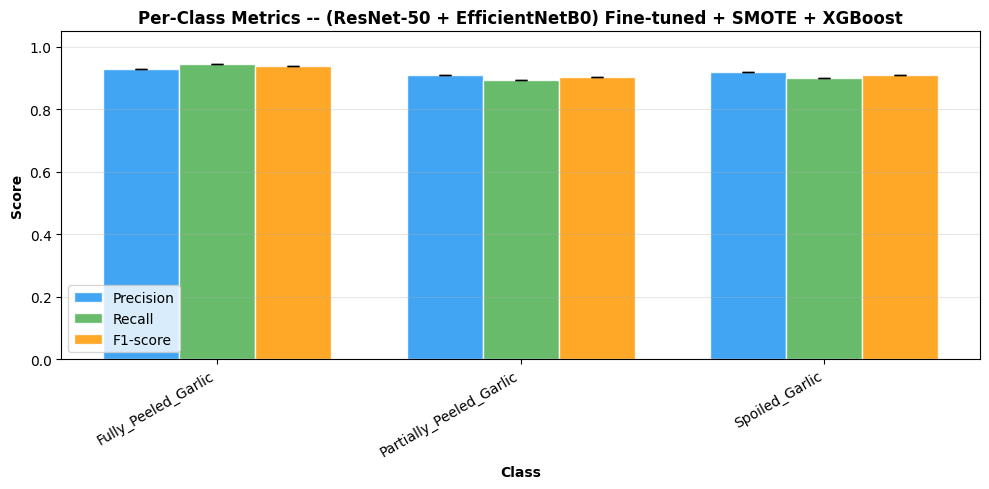

In [11]:
# ========== 11. PER-CLASS METRICS BAR CHART ========== #

metrics_to_plot = ['precision', 'recall', 'f1-score']
x = np.arange(len(class_names))
bar_w = 0.25
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(max(10, len(class_names) * 1.5), 5))
for i, metric in enumerate(metrics_to_plot):
    means = [per_class_stats[cn][metric]['mean'] for cn in class_names]
    stds  = [per_class_stats[cn][metric]['std']  for cn in class_names]
    ax.bar(x + i * bar_w, means, bar_w, yerr=stds, label=metric.capitalize(),
           color=colors[i], alpha=0.85, capsize=4, edgecolor='white')

ax.set_xlabel('Class', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title(f'Per-Class Metrics -- {STRATEGY_LABEL}',
             fontweight='bold')
ax.set_xticks(x + bar_w)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_RESULT_DIR, 'per_class_metrics.png'), dpi=300)
plt.show()

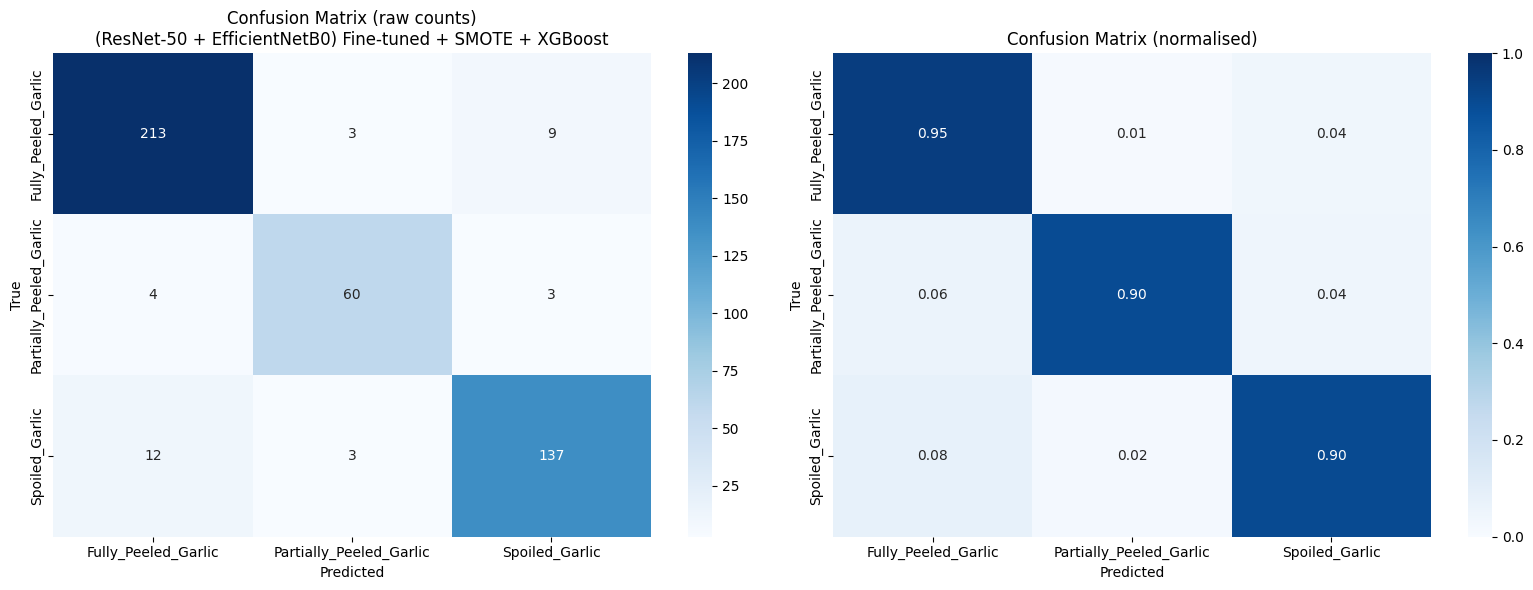

In [12]:
# ========== 12. CONFUSION MATRIX ========== #

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title(f'Confusion Matrix (raw counts)\n{STRATEGY_LABEL}')

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', ax=axes[1], vmin=0, vmax=1)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (normalised)')

plt.tight_layout()
plt.savefig(os.path.join(BASE_RESULT_DIR, 'confusion_matrix.png'), dpi=300)
plt.show()

/tmp/ipykernel_23/1184507536.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', nc)


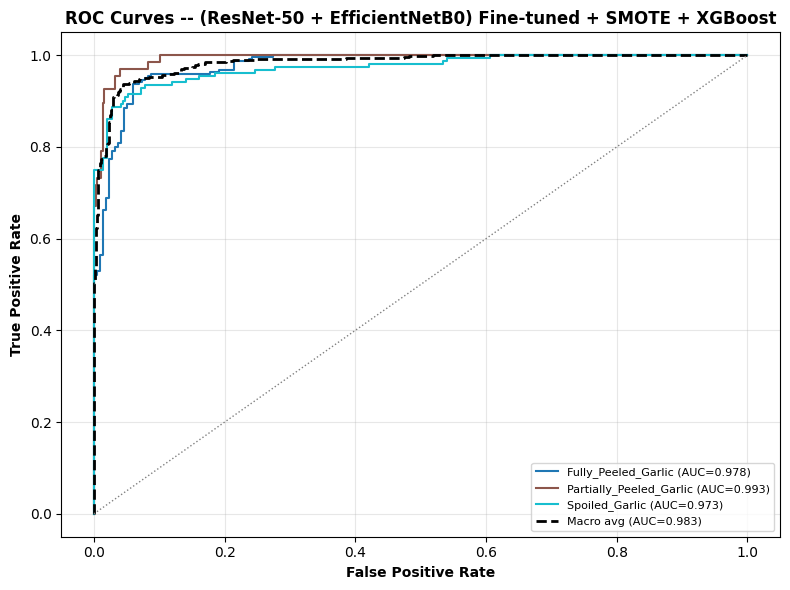

Macro-average AUC: 0.9834


In [13]:
# ========== 13. ROC CURVES ========== #

nc    = len(class_names)
y_bin = label_binarize(y_test, classes=list(range(nc)))
fpr_m, tpr_m, _ = roc_curve(y_bin.ravel(), pred_probs.ravel())
auc_m = auc(fpr_m, tpr_m)

fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.cm.get_cmap('tab10', nc)
for i, cn in enumerate(class_names):
    fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], pred_probs[:, i])
    ax.plot(fpr_i, tpr_i, color=cmap(i),
            label=f'{cn} (AUC={auc(fpr_i, tpr_i):.3f})', linewidth=1.5)
ax.plot(fpr_m, tpr_m, 'k--', label=f'Macro avg (AUC={auc_m:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'gray', linestyle=':', linewidth=1)
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title(f'ROC Curves -- {STRATEGY_LABEL}',
             fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_RESULT_DIR, 'roc_curves.png'), dpi=300)
plt.show()
print(f"Macro-average AUC: {auc_m:.4f}")

Feature Importance by Backbone:
  ResNet-50      : 74.2%  (sum=0.7418)
  EfficientNetB0 : 25.8%  (sum=0.2582)


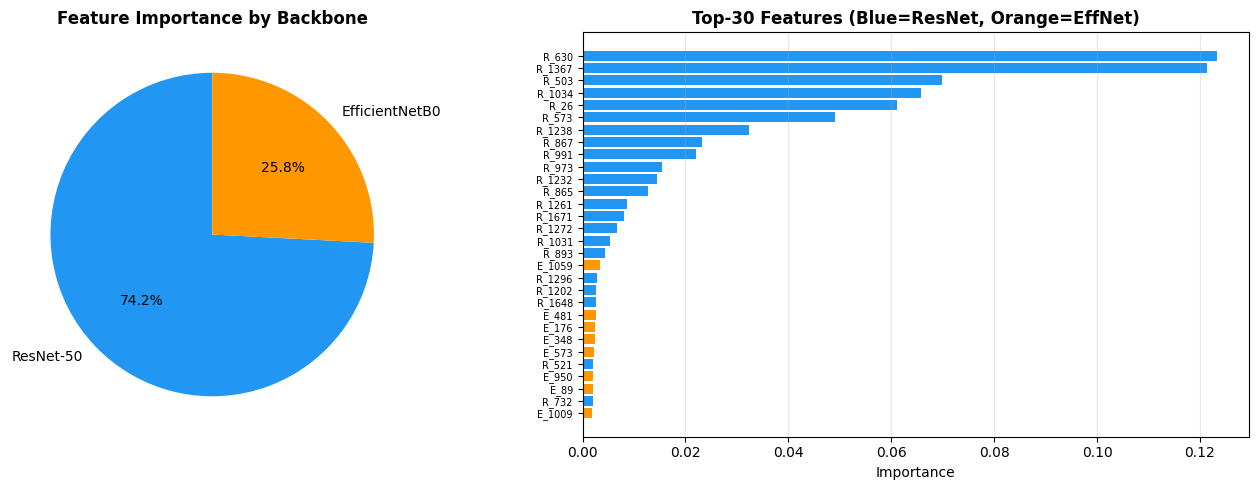

In [14]:
# ========== 14. XGBOOST FEATURE IMPORTANCE ========== #

importance = xgb_model.feature_importances_
feat_dim_resnet = 2048
feat_dim_effnet = 1280

# Aggregate importance by backbone
resnet_imp = importance[:feat_dim_resnet].sum()
effnet_imp = importance[feat_dim_resnet:].sum()
total_imp  = resnet_imp + effnet_imp

print("Feature Importance by Backbone:")
print(f"  ResNet-50      : {resnet_imp/total_imp*100:.1f}%  (sum={resnet_imp:.4f})")
print(f"  EfficientNetB0 : {effnet_imp/total_imp*100:.1f}%  (sum={effnet_imp:.4f})")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Backbone contribution pie
axes[0].pie([resnet_imp, effnet_imp],
            labels=['ResNet-50', 'EfficientNetB0'],
            autopct='%1.1f%%', colors=['#2196F3', '#FF9800'],
            startangle=90)
axes[0].set_title('Feature Importance by Backbone', fontweight='bold')

# Top-30 features
top_k = 30
top_idx = np.argsort(importance)[-top_k:][::-1]
top_imp = importance[top_idx]
top_labels = []
for idx in top_idx:
    if idx < feat_dim_resnet:
        top_labels.append(f'R_{idx}')
    else:
        top_labels.append(f'E_{idx - feat_dim_resnet}')

colors_bar = ['#2196F3' if idx < feat_dim_resnet else '#FF9800' for idx in top_idx]
axes[1].barh(range(top_k), top_imp[::-1], color=colors_bar[::-1])
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels(top_labels[::-1], fontsize=7)
axes[1].set_xlabel('Importance')
axes[1].set_title(f'Top-{top_k} Features (Blue=ResNet, Orange=EffNet)', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_RESULT_DIR, 'feature_importance.png'), dpi=300)
plt.show()

Running t-SNE on 444 samples x 3328 dims...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_23/3955651892.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', len(class_names))


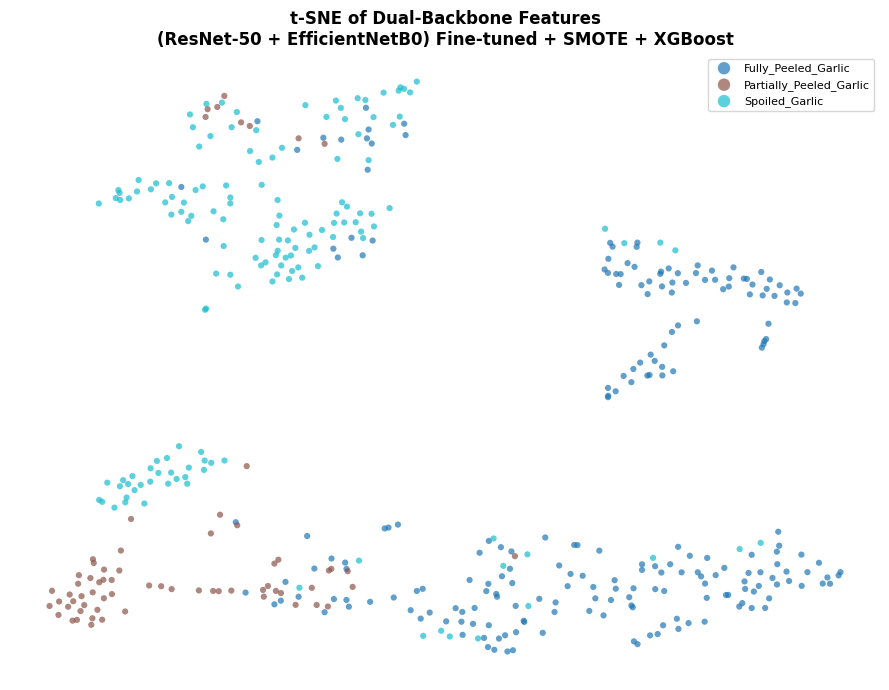

Saved t-SNE visualization -> /kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/tsne.png


In [15]:
# ========== 15. t-SNE FEATURE VISUALIZATION ========== #

print(f"Running t-SNE on {X_test.shape[0]} samples x {X_test.shape[1]} dims...")
tsne   = TSNE(n_components=2, perplexity=30, random_state=SEED,
              n_iter=1000, verbose=0)
coords = tsne.fit_transform(X_test)

fig, ax = plt.subplots(figsize=(9, 7))
cmap    = plt.cm.get_cmap('tab10', len(class_names))
for ci, cn in enumerate(class_names):
    mask = y_test == ci
    ax.scatter(coords[mask, 0], coords[mask, 1],
               color=cmap(ci), label=cn, alpha=0.7, s=20, edgecolors='none')
ax.set_title(f't-SNE of Dual-Backbone Features\n{STRATEGY_LABEL}',
             fontweight='bold')
ax.legend(loc='upper right', fontsize=8, markerscale=2)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(BASE_RESULT_DIR, 'tsne.png'), dpi=300)
plt.show()
print(f"Saved t-SNE visualization -> {BASE_RESULT_DIR}/tsne.png")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


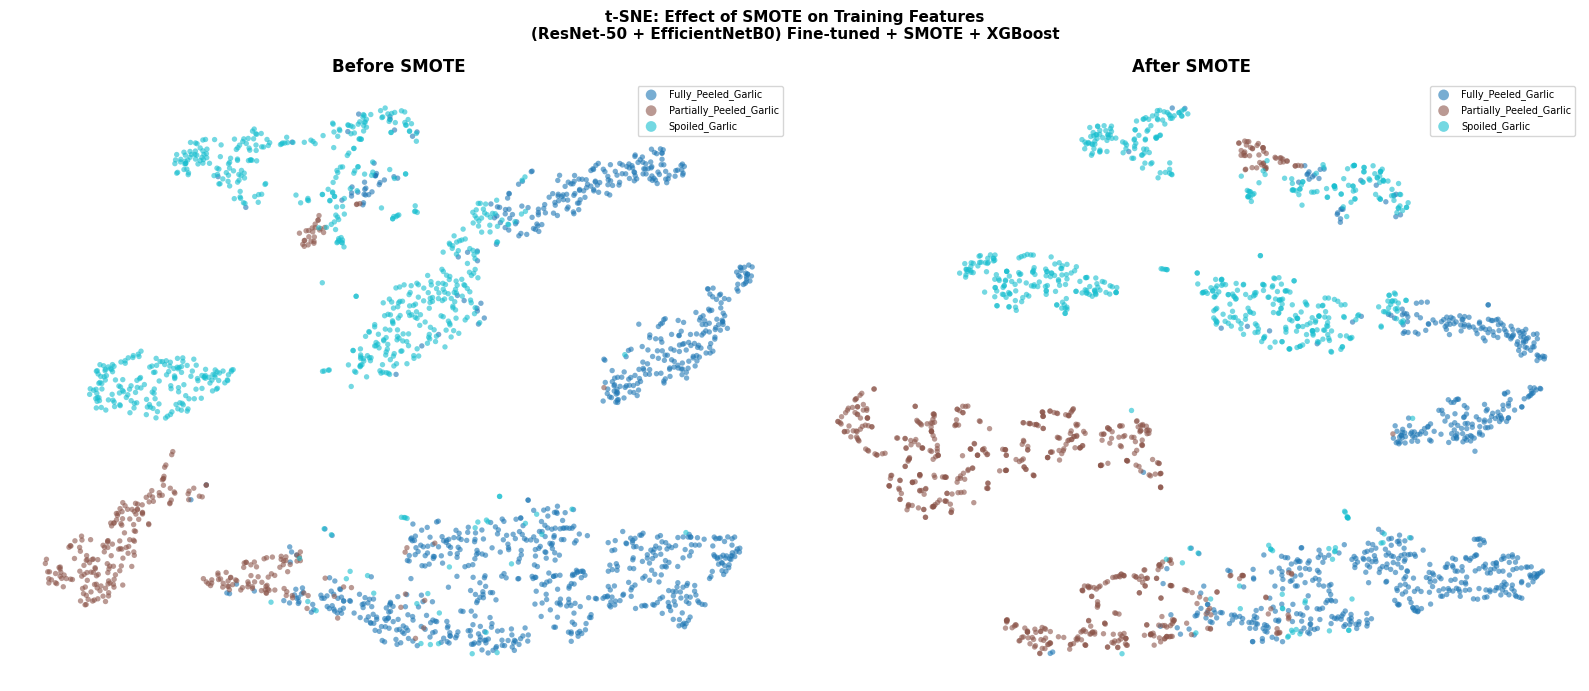

Saved SMOTE comparison -> /kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/tsne_smote_comparison.png


In [16]:
# ========== 16. t-SNE: BEFORE vs AFTER SMOTE ========== #
# Visualize the effect of SMOTE in feature space.

# Subsample for speed (max 2000 per set)
max_tsne = 2000
if X_train.shape[0] > max_tsne:
    idx_sub = np.random.choice(X_train.shape[0], max_tsne, replace=False)
    X_train_sub, y_train_sub = X_train[idx_sub], y_train[idx_sub]
else:
    X_train_sub, y_train_sub = X_train, y_train

if X_train_sm.shape[0] > max_tsne:
    idx_sub_sm = np.random.choice(X_train_sm.shape[0], max_tsne, replace=False)
    X_sm_sub, y_sm_sub = X_train_sm[idx_sub_sm], y_train_sm[idx_sub_sm]
else:
    X_sm_sub, y_sm_sub = X_train_sm, y_train_sm

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, X_sub, y_sub, title in [
    (axes[0], X_train_sub, y_train_sub, 'Before SMOTE'),
    (axes[1], X_sm_sub,    y_sm_sub,    'After SMOTE'),
]:
    tsne_sub = TSNE(n_components=2, perplexity=30, random_state=SEED,
                    n_iter=800, verbose=0)
    coords_sub = tsne_sub.fit_transform(X_sub)
    for ci, cn in enumerate(class_names):
        mask = y_sub == ci
        ax.scatter(coords_sub[mask, 0], coords_sub[mask, 1],
                   color=cmap(ci), label=cn, alpha=0.6, s=15, edgecolors='none')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7, markerscale=2)
    ax.axis('off')

fig.suptitle(f't-SNE: Effect of SMOTE on Training Features\n{STRATEGY_LABEL}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_RESULT_DIR, 'tsne_smote_comparison.png'), dpi=300)
plt.show()
print(f"Saved SMOTE comparison -> {BASE_RESULT_DIR}/tsne_smote_comparison.png")

In [17]:
# ========== 17. INFERENCE SPEED BENCHMARK ========== #

# Warm-up
_ = xgb_model.predict_proba(X_test[:10])

# XGBoost inference speed (feature extraction excluded)
n_repeats = 10
t0 = time.perf_counter()
for _ in range(n_repeats):
    _ = xgb_model.predict_proba(X_test)
total_t = (time.perf_counter() - t0) / n_repeats

ms_per_img   = total_t / X_test.shape[0] * 1000
imgs_per_sec = X_test.shape[0] / total_t

print("=" * 50)
print("INFERENCE SPEED BENCHMARK (XGBoost only, features pre-extracted)")
print(f"  Test images    : {X_test.shape[0]}")
print(f"  Total time     : {total_t:.4f} s  (avg of {n_repeats} runs)")
print(f"  ms / image     : {ms_per_img:.3f} ms")
print(f"  Images / second: {imgs_per_sec:.0f}")
print("=" * 50)

INFERENCE SPEED BENCHMARK (XGBoost only, features pre-extracted)
  Test images    : 444
  Total time     : 0.0176 s  (avg of 10 runs)
  ms / image     : 0.040 ms
  Images / second: 25223


In [18]:
# ========== 18. MODEL SUMMARY ========== #

print("=" * 60)
print("MODEL SUMMARY")
print(f"  Architecture : (ResNet-50 + EfficientNetB0) Fine-tuned + SMOTE + XGBoost")
print(f"  ResNet-50    : 2048-d features (fine-tuned conv5 block)")
print(f"  EfficientNetB0: 1280-d features (fine-tuned blocks {EFFNET_UNFREEZE_BLOCKS})")
print(f"  Fused dim    : 3328")
print(f"  Fine-tune    : {FT_EPOCHS} epochs, LR={FT_LR}")
print(f"  SMOTE k      : {SMOTE_K}")
print(f"  XGBoost trees: {xgb_model.best_iteration + 1} (best of {XGB_PARAMS['n_estimators']})")
print(f"  Max depth    : {XGB_PARAMS['max_depth']}")
print(f"  Learning rate: {XGB_PARAMS['learning_rate']}")
print(f"  Train samples: {X_train.shape[0]} -> {X_train_sm.shape[0]} (after SMOTE)")
print(f"  Val samples  : {X_val.shape[0]}")
print(f"  Test samples : {X_test.shape[0]}")
print("=" * 60)

MODEL SUMMARY
  Architecture : (ResNet-50 + EfficientNetB0) Fine-tuned + SMOTE + XGBoost
  ResNet-50    : 2048-d features (fine-tuned conv5 block)
  EfficientNetB0: 1280-d features (fine-tuned blocks [5, 6, 7])
  Fused dim    : 3328
  Fine-tune    : 20 epochs, LR=0.0001
  SMOTE k      : 5
  XGBoost trees: 108 (best of 500)
  Max depth    : 8
  Learning rate: 0.05
  Train samples: 2060 -> 3150 (after SMOTE)
  Val samples  : 440
  Test samples : 444


In [ ]:
# ========== 19. EXPORT FINAL REPORT ========== #

report_path = os.path.join(BASE_RESULT_DIR, 'final_report.csv')
with open(report_path, 'w', newline='') as f:
    fields = [
        'strategy_key', 'strategy_label',
        'backbone', 'fine_tuned', 'ft_epochs', 'ft_lr',
        'use_l2_norm', 'use_pca', 'pca_components',
        'smote_type', 'smote_k',
        'xgb_n_estimators', 'xgb_max_depth', 'xgb_lr',
        'run', 'seed',
        'accuracy', 'top3_accuracy', 'precision', 'recall', 'f1_score',
        'kappa', 'mcc', 'balanced_accuracy',
    ]
    writer = csv.DictWriter(f, fieldnames=fields)
    writer.writeheader()
    for r in all_runs_results:
        writer.writerow({
            'strategy_key':      STRATEGY_KEY,
            'strategy_label':    STRATEGY_LABEL,
            'backbone':          'ResNet50+EfficientNetB0',
            'fine_tuned':        True,
            'ft_epochs':         FT_EPOCHS,
            'ft_lr':             FT_LR,
            'use_l2_norm':       USE_L2_NORM,
            'use_pca':           USE_PCA,
            'pca_components':    PCA_COMPONENTS if USE_PCA else 'N/A',
            'smote_type':        'BorderlineSMOTE',
            'smote_k':           SMOTE_K,
            'xgb_n_estimators':  xgb_model.best_iteration + 1,
            'xgb_max_depth':     XGB_PARAMS['max_depth'],
            'xgb_lr':            XGB_PARAMS['learning_rate'],
            'run':               r['run'],
            'seed':              r['seed'],
            'accuracy':          f"{r['accuracy']:.6f}",
            'top3_accuracy':     f"{r['top3_accuracy']:.6f}",
            'precision':         f"{r['precision']:.6f}",
            'recall':            f"{r['recall']:.6f}",
            'f1_score':          f"{r['f1_score']:.6f}",
            'kappa':             f"{r['kappa']:.6f}",
            'mcc':               f"{r['mcc']:.6f}",
            'balanced_accuracy': f"{r['balanced_accuracy']:.6f}",
        })

summary_path = os.path.join(BASE_RESULT_DIR, 'strategy_summary.csv')
with open(summary_path, 'w', newline='') as csvf:
    fieldnames = ['strategy_key', 'strategy_label',
                  'run', 'seed', 'accuracy', 'top3_accuracy',
                  'precision', 'recall', 'f1_score', 'kappa', 'mcc', 'balanced_accuracy']
    writer = csv.DictWriter(csvf, fieldnames=fieldnames)
    writer.writeheader()
    for r in all_runs_results:
        writer.writerow({
            'strategy_key':      STRATEGY_KEY,
            'strategy_label':    STRATEGY_LABEL,
            'run':               r['run'],
            'seed':              r['seed'],
            'accuracy':          r['accuracy'],
            'top3_accuracy':     r['top3_accuracy'],
            'precision':         r['precision'],
            'recall':            r['recall'],
            'f1_score':          r['f1_score'],
            'kappa':             r['kappa'],
            'mcc':               r['mcc'],
            'balanced_accuracy': r['balanced_accuracy'],
        })

acc_mean = np.mean([r['accuracy'] for r in all_runs_results])
f1_mean  = np.mean([r['f1_score'] for r in all_runs_results])

print("=" * 60)
print("FINAL REPORT")
print(f"  {STRATEGY_LABEL}")
print(f"  Accuracy       : {acc_mean:.4f}")
print(f"  F1-Score       : {f1_mean:.4f}")
print(f"  Saved          : {report_path}")
print(f"  Summary        : {summary_path}")
print("=" * 60)

print("\nAll outputs saved to:", BASE_RESULT_DIR)
for fname in sorted(os.listdir(BASE_RESULT_DIR)):
    print(f"  {fname}")


FINAL REPORT
  (ResNet-50 + EfficientNetB0) Fine-tuned + SMOTE + XGBoost
  Accuracy : 0.9234
  F1-Score : 0.9233
  Saved    : /kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/final_report.csv
  Summary  : /kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/strategy_summary.csv

All outputs saved to: /kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost
  confusion_matrix.png
  feature_importance.png
  final_report.csv
  overall_metrics_summary.csv
  per_class_metrics.png
  roc_curves.png
  run_1_seed_42
  strategy_summary.csv
  tsne.png
  tsne_smote_comparison.png


In [20]:
!zip -r /kaggle/working/resnet50_effb0_smote_xgboost.zip /kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost

  adding: kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/ (stored 0%)
  adding: kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/per_class_metrics.png (deflated 20%)
  adding: kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/run_1_seed_42/ (stored 0%)
  adding: kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/run_1_seed_42/resnet50_training_log.csv (deflated 52%)
  adding: kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/run_1_seed_42/effnetb0_training_log.csv (deflated 53%)
  adding: kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/run_1_seed_42/effnetb0_learning_curve.png (deflated 11%)
  adding: kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/run_1_seed_42/xgboost_model.json (deflated 72%)
  adding: kaggle/working/report_EfficientNetB4/resnet50_effb0_smote_xgboost/run_1_seed_42/resnet50_best.keras (deflated 13%)
  adding: kaggle/working/report_EfficientNetB4/resn